# NOWCASTING VAB MANABÍ 2026

## Dashboard de Predicción en Tiempo Real — Ridge + GAM

### Demostración de predicción de alta frecuencia con análisis de sentimiento

---

- Sección 1: Resumen de Validación (2024-2025)
- Sección 2: Nowcasting 2026 — Ridge vs GAM

**Objetivo:** Comparar nowcasting 2026 con los dos mejores modelos validados

In [ ]:
# Setup
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# pygam
try:
    from pygam import LinearGAM, s, l
    print("pygam disponible")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pygam", "-q"])
    from pygam import LinearGAM, s, l

drive.mount('/content/drive')
path_proyecto = "/content/drive/MyDrive/TitulacionF"

print("NOWCASTING VAB MANABÍ 2026  —  Ridge + GAM")
print("="*70)
print(f"Fecha: {datetime.now().strftime('%d/%m/%Y %H:%M')}")
print("\nLibrerías cargadas correctamente")

Mounted at /content/drive
NOWCASTING VAB MANABÍ 2026  —  Ridge + GAM
Fecha: 09/05/2026 23:03

Librerías cargadas correctamente


In [ ]:
# Cargar datos
print("\nCargando datos...")

try:
    df_sentimiento = pd.read_csv(f"{path_proyecto}/sentimiento_mensual_2020_2026.csv")
except:
    df_sentimiento = pd.read_csv(f"{path_proyecto}/sentimiento_mensual_2020_2024.csv")

print(f"Datos cargados: {len(df_sentimiento)} filas")
print(f"Años: {sorted(df_sentimiento['año'].unique())}")

# Cargar VAB histórico
df_vab = pd.read_csv(f"{path_proyecto}/vab_manabi_2020_2023.csv")

# VAB conocidos (oficiales BCE)
VAB_2024_REAL = 5768.40
VAB_2025_REAL = 5956.70

print("\nVAB oficiales (BCE):")
print(f"  2024: ${VAB_2024_REAL:,.2f}M")
print(f"  2025: ${VAB_2025_REAL:,.2f}M")


Cargando datos...
Datos cargados: 75 filas
Años: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

VAB oficiales (BCE):
  2024: $5,768.40M
  2025: $5,956.70M


---

# SECCIÓN 1: RESUMEN DE VALIDACIÓN

## Resultados en años anteriores (2024-2025)

---

In [ ]:
# Resultados validados (NB3 y NB4) — los tres modelos
print("\n" + "="*70)
print("RESUMEN DE VALIDACIÓN 2024-2025")
print("="*70)

resultados = {
    'Año':               ['2024',    '2025',    'Promedio'],
    'VAB Real (M USD)':  [5768.40,   5956.70,   5862.55],
    'ARIMA Error (%)':   [2.01,      3.03,      2.52],
    'Ridge Error (%)':   [0.40,      1.72,      1.06],
    'GAM Error (%)':     [0.84,      0.65,      0.75],
}

df_resultados = pd.DataFrame(resultados)

print("\nResultados de validación:")
print(df_resultados.to_string(index=False))

print("\nConclusiones principales:")
print("  - GAM tiene el mejor promedio de 2 años: 0.75%")
print("  - Ridge ganó en 2024 (0.40%), GAM ganó en 2025 (0.65%)")
print("  - Ambos modelos con sentimiento superan a ARIMA en los dos años")
print("  - ARIMA promedio: 2.52%  |  Ridge promedio: 1.06%  |  GAM promedio: 0.75%")


RESUMEN DE VALIDACIÓN 2024-2025

Resultados de validación:
     Año  VAB Real (M USD)  ARIMA Error (%)  Ridge Error (%)  GAM Error (%)
    2024           5768.40             2.01             0.40           0.84
    2025           5956.70             3.03             1.72           0.65
Promedio           5862.55             2.52             1.06           0.75

Conclusiones principales:
  - GAM tiene el mejor promedio de 2 años: 0.75%
  - Ridge ganó en 2024 (0.40%), GAM ganó en 2025 (0.65%)
  - Ambos modelos con sentimiento superan a ARIMA en los dos años
  - ARIMA promedio: 2.52%  |  Ridge promedio: 1.06%  |  GAM promedio: 0.75%


---

# SECCIÓN 2: NOWCASTING 2026 EN TIEMPO REAL

## Predicción adaptable — Ridge (alpha=0.1) y GAM (s(n_splines=5) para las 7 variables)

---

In [ ]:
# Detectar datos 2026
df_2026 = df_sentimiento[df_sentimiento['año'] == 2026].copy()
meses_disponibles = sorted(df_2026['mes'].unique()) if len(df_2026) > 0 else []

print("\n" + "="*70)
print("NOWCASTING VAB 2026")
print("="*70)

if len(meses_disponibles) == 0:
    print("\nNo hay datos de 2026 disponibles")
    print("\nPara generar nowcasting:")
    print("  1. Ejecutar scraping de noticias 2026")
    print("  2. Procesar con análisis de sentimiento")
    print("  3. Re-ejecutar este notebook")
else:
    print(f"\nMeses detectados: {len(meses_disponibles)}/12")
    print(f"Cobertura: {len(meses_disponibles)/12*100:.0f}%")
    print(f"Último mes: {max(meses_disponibles)}/2026")

    # Nivel de confianza según meses
    if len(meses_disponibles) <= 2:
        confianza = "Muy Baja"
        incertidumbre = 0.15
    elif len(meses_disponibles) <= 4:
        confianza = "Baja"
        incertidumbre = 0.12
    elif len(meses_disponibles) <= 6:
        confianza = "Media"
        incertidumbre = 0.08
    elif len(meses_disponibles) <= 9:
        confianza = "Alta"
        incertidumbre = 0.05
    else:
        confianza = "Muy Alta"
        incertidumbre = 0.03

    print(f"Nivel de confianza: {confianza}")
    print(f"Incertidumbre: ±{incertidumbre*100:.0f}%")


NOWCASTING VAB 2026

Meses detectados: 3/12
Cobertura: 25%
Último mes: 3/2026
Nivel de confianza: Baja
Incertidumbre: ±12%


In [ ]:
# Entrenar Ridge y GAM con 2020-2025
if len(meses_disponibles) > 0:
    print("\nPreparando datos de entrenamiento 2020-2025...")

    df_train = df_sentimiento[df_sentimiento['año'].between(2020, 2025)].copy()
    df_train = df_train.sort_values('año_mes').reset_index(drop=True)

    vab_dict = {
        2020: df_vab[df_vab['año']==2020]['vab_corriente'].values[0],
        2021: df_vab[df_vab['año']==2021]['vab_corriente'].values[0],
        2022: df_vab[df_vab['año']==2022]['vab_corriente'].values[0],
        2023: df_vab[df_vab['año']==2023]['vab_corriente'].values[0],
        2024: VAB_2024_REAL,
        2025: VAB_2025_REAL
    }

    df_train['vab_mensual']      = df_train['año'].map(vab_dict) / 12
    df_train['vab_variacion_pct']= df_train['vab_mensual'].pct_change() * 100
    df_train['vab_mes_anterior'] = df_train['vab_mensual'].shift(1)
    df_train['vab_promedio_3m']  = df_train['vab_mensual'].rolling(3, min_periods=1).mean()

    feature_cols = ['sentimiento_promedio', 'pct_positivas', 'pct_negativas',
                    'volatilidad_movil_3m', 'num_noticias',
                    'vab_mes_anterior', 'vab_promedio_3m']

    df_train_clean = df_train.dropna(subset=['vab_variacion_pct'] + feature_cols)
    X_train = df_train_clean[feature_cols].values
    y_train = df_train_clean['vab_variacion_pct'].values

    # Rangos para normalización
    rangos = {col: {'max':  df_train_clean[col].max(),
                    'mean': df_train_clean[col].mean()}
              for col in feature_cols}

    # ── RIDGE ──────────────────────────────────────────────────────────────
    modelo_ridge = Ridge(alpha=0.1)
    modelo_ridge.fit(X_train, y_train)
    r2_ridge = r2_score(y_train, modelo_ridge.predict(X_train))
    print(f"\nRidge entrenado   | R²={r2_ridge:.4f} | obs={len(y_train)}")

    # ── GAM  (EXP-1: l() en autoregresivas, s() en sentimiento) ───────────
    # Índices: 0=sent_prom, 1=pct_pos, 2=pct_neg, 3=vol_3m, 4=num_not,
    #          5=vab_ant (lineal), 6=vab_3m (lineal)
    modelo_gam = LinearGAM(
        s(0, n_splines=5) +   # sentimiento_promedio
        s(1, n_splines=5) +   # pct_positivas
        s(2, n_splines=5) +   # pct_negativas
        s(3, n_splines=5) +   # volatilidad_movil_3m
        s(4, n_splines=5) +   # num_noticias
        s(5, n_splines=5) +   # vab_mes_anterior
        s(6, n_splines=5)     # vab_promedio_3m
    )
    modelo_gam.fit(X_train, y_train)
    r2_gam = r2_score(y_train, modelo_gam.predict(X_train))
    print(f"GAM    entrenado  | R²={r2_gam:.4f} | s(n_splines=5) para las 7 variables")

    print(f"\nnum_noticias — max_train={rangos['num_noticias']['max']:.0f} | mean_train={rangos['num_noticias']['mean']:.0f}")


Preparando datos de entrenamiento 2020-2025...

Ridge entrenado   | R²=0.5309 | obs=71
GAM    entrenado  | R²=0.5862 | s(n_splines=5) para las 7 variables

num_noticias — max_train=568 | mean_train=151


In [ ]:
# Nowcasting 2026 — Ridge y GAM mes por mes
if len(meses_disponibles) > 0:
    print("\nPrediciendo VAB 2026 mes por mes (Ridge y GAM)...")
    print("="*70)

    # ── Inicialización compartida ──────────────────────────────────────────
    vab_init = VAB_2025_REAL / 12

    # Listas de predicciones
    pred_ridge = []
    pred_gam   = []

    vab_act_ridge, vab_3m_ridge = vab_init, vab_init
    vab_act_gam,   vab_3m_gam   = vab_init, vab_init

    print(f"\nInicialización: VAB_mensual_base = ${vab_init:.2f}M (VAB 2025 / 12)")
    print("-"*70)
    print(f"{'Mes':>4} | {'Δ Ridge':>8} | {'VAB Ridge':>10} | {'Δ GAM':>8} | {'VAB GAM':>10} | {'Sentim':>7}")
    print("-"*70)

    def normalizar_noticias(n, rangos):
        max_t  = rangos['num_noticias']['max']
        mean_t = rangos['num_noticias']['mean']
        if n > max_t:
            return mean_t * ((n / mean_t) ** 0.75)
        return n

    for mes in meses_disponibles:
        row = df_2026[df_2026['mes'] == mes].iloc[0]
        num_orig = row['num_noticias']
        num_norm = normalizar_noticias(num_orig, rangos)

        # ── RIDGE ────────────────────────────────────────────────────────
        f_ridge = [row['sentimiento_promedio'], row['pct_positivas'],
                   row['pct_negativas'], row['volatilidad_movil_3m'],
                   num_norm, vab_act_ridge, vab_3m_ridge]
        var_ridge = float(np.clip(modelo_ridge.predict([f_ridge])[0], -10, 10))
        vab_nuevo_ridge = vab_act_ridge * (1 + var_ridge / 100)
        pred_ridge.append({'mes': mes, 'vab': vab_nuevo_ridge, 'variacion': var_ridge,
                           'sentimiento': row['sentimiento_promedio'], 'num_noticias': num_orig})
        vab_act_ridge = vab_nuevo_ridge
        if len(pred_ridge) >= 3:
            vab_3m_ridge = np.mean([p['vab'] for p in pred_ridge[-3:]])

        # ── GAM ──────────────────────────────────────────────────────────
        f_gam = [row['sentimiento_promedio'], row['pct_positivas'],
                 row['pct_negativas'], row['volatilidad_movil_3m'],
                 num_norm, vab_act_gam, vab_3m_gam]
        var_gam = float(np.clip(modelo_gam.predict([f_gam])[0], -7, 7))
        vab_nuevo_gam = vab_act_gam * (1 + var_gam / 100)
        pred_gam.append({'mes': mes, 'vab': vab_nuevo_gam, 'variacion': var_gam,
                         'sentimiento': row['sentimiento_promedio'], 'num_noticias': num_orig})
        vab_act_gam = vab_nuevo_gam
        if len(pred_gam) >= 3:
            vab_3m_gam = np.mean([p['vab'] for p in pred_gam[-3:]])

        print(f"  {mes:>2} | {var_ridge:>+7.2f}% | ${vab_nuevo_ridge:>9.2f}M | {var_gam:>+7.2f}% | ${vab_nuevo_gam:>9.2f}M | {row['sentimiento_promedio']:>+6.3f}")

    df_pred_ridge = pd.DataFrame(pred_ridge)
    df_pred_gam   = pd.DataFrame(pred_gam)

    n_meses = len(meses_disponibles)
    incertidumbre = 0.01  # ±1%

    vab_parcial_ridge = df_pred_ridge['vab'].sum()
    vab_anual_ridge   = vab_parcial_ridge * (12 / n_meses)

    vab_parcial_gam   = df_pred_gam['vab'].sum()
    vab_anual_gam     = vab_parcial_gam * (12 / n_meses)

    print("\n" + "="*70)
    print("PROYECCIÓN VAB 2026")
    print("="*70)
    print(f"  Meses disponibles: {n_meses}/12")
    print(f"\n  Ridge — VAB proyectado: ${vab_anual_ridge:,.2f}M  "
          f"(rango: ${vab_anual_ridge*(1-incertidumbre):,.2f}M – ${vab_anual_ridge*(1+incertidumbre):,.2f}M)")
    print(f"  Ridge — Variación vs 2025: {((vab_anual_ridge/VAB_2025_REAL)-1)*100:+.2f}%")
    print(f"\n  GAM   — VAB proyectado: ${vab_anual_gam:,.2f}M  "
          f"(rango: ${vab_anual_gam*(1-incertidumbre):,.2f}M – ${vab_anual_gam*(1+incertidumbre):,.2f}M)")
    print(f"  GAM   — Variación vs 2025: {((vab_anual_gam/VAB_2025_REAL)-1)*100:+.2f}%")
    print(f"\n  VAB Real 2025 (referencia): ${VAB_2025_REAL:,.2f}M")


Prediciendo VAB 2026 mes por mes (Ridge y GAM)...

Inicialización: VAB_mensual_base = $496.39M (VAB 2025 / 12)
----------------------------------------------------------------------
 Mes |  Δ Ridge |  VAB Ridge |    Δ GAM |    VAB GAM |  Sentim
----------------------------------------------------------------------
   1 |   -0.05% | $   496.14M |   +0.32% | $   497.97M | +0.193
   2 |   +0.06% | $   496.43M |   -0.53% | $   495.35M | +0.341
   3 |   -0.01% | $   496.40M |   +0.60% | $   498.32M | +0.233

PROYECCIÓN VAB 2026
  Meses disponibles: 3/12

  Ridge — VAB proyectado: $5,955.86M  (rango: $5,896.30M – $6,015.42M)
  Ridge — Variación vs 2025: -0.01%

  GAM   — VAB proyectado: $5,966.58M  (rango: $5,906.92M – $6,026.25M)
  GAM   — Variación vs 2025: +0.17%

  VAB Real 2025 (referencia): $5,956.70M


In [ ]:
# Gráfico comparativo Ridge vs GAM — Nowcasting 2026
if len(meses_disponibles) > 0:
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=("VAB Mensual Predicho 2026 — Ridge vs GAM",
                        "Sentimiento mensual 2026"),
        vertical_spacing=0.12,
        specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
    )

    # VAB mensual — Ridge
    fig.add_trace(
        go.Scatter(x=df_pred_ridge['mes'], y=df_pred_ridge['vab'],
                   mode='lines+markers', name='Ridge',
                   line=dict(color='orange', width=3), marker=dict(size=9, symbol='square'),
                   hovertemplate='Mes %{x}<br>VAB Ridge: $%{y:.2f}M<extra></extra>'),
        row=1, col=1
    )

    # VAB mensual — GAM
    fig.add_trace(
        go.Scatter(x=df_pred_gam['mes'], y=df_pred_gam['vab'],
                   mode='lines+markers', name='GAM',
                   line=dict(color='purple', width=3, dash='dash'), marker=dict(size=9, symbol='diamond'),
                   hovertemplate='Mes %{x}<br>VAB GAM: $%{y:.2f}M<extra></extra>'),
        row=1, col=1
    )

    # Sentimiento
    fig.add_trace(
        go.Bar(x=df_pred_ridge['mes'], y=df_pred_ridge['sentimiento'],
               name='Sentimiento', marker_color=[
                   'green' if s >= 0 else 'red' for s in df_pred_ridge['sentimiento']
               ], opacity=0.7,
               hovertemplate='Mes %{x}<br>Sentimiento: %{y:.3f}<extra></extra>'),
        row=2, col=1
    )

    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=2, col=1)

    vab_anual_ridge_lbl = df_pred_ridge['vab'].sum() * (12 / len(meses_disponibles))
    vab_anual_gam_lbl   = df_pred_gam['vab'].sum()   * (12 / len(meses_disponibles))

    fig.update_layout(
        height=600,
        title_text=f"Nowcasting VAB Manabí 2026 — {len(meses_disponibles)} meses disponibles<br>"
                   f"Ridge: ${vab_anual_ridge_lbl:,.0f}M | GAM: ${vab_anual_gam_lbl:,.0f}M",
        title_font_size=15,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        template="plotly_white"
    )
    fig.update_yaxes(title_text="VAB Mensual (M USD)", row=1, col=1)
    fig.update_yaxes(title_text="Sentimiento promedio", row=2, col=1)
    fig.update_xaxes(title_text="Mes", row=2, col=1)

    fig.show()

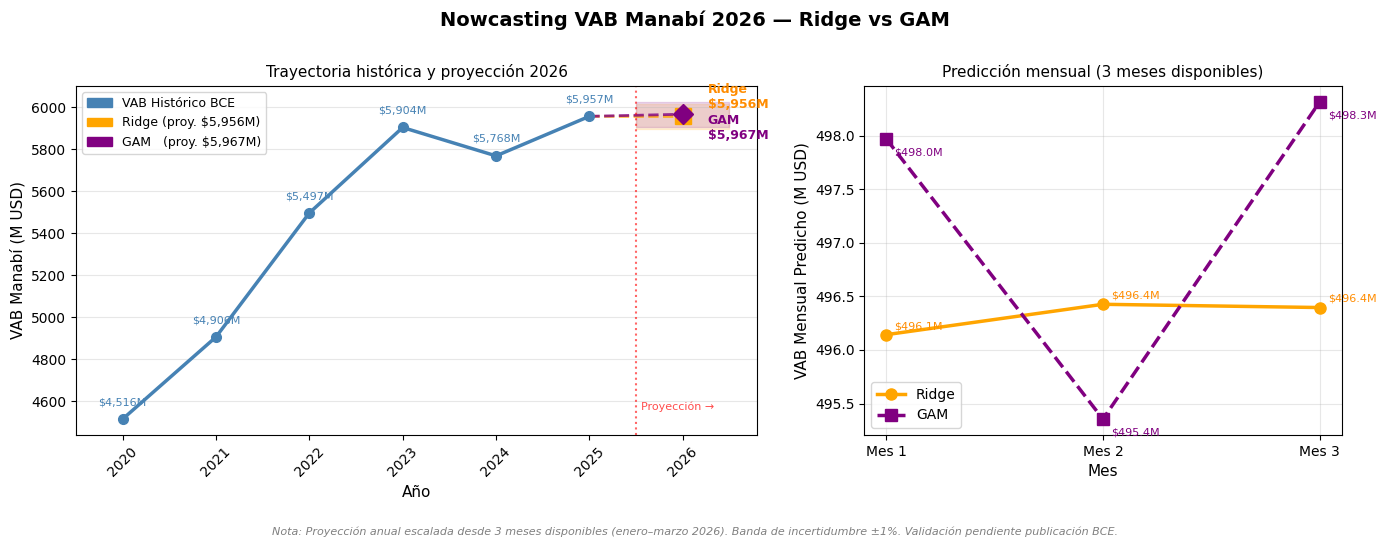


Ridge proyección anual: $5,955.86M
GAM   proyección anual: $5,966.58M


In [ ]:
# Gráfico nowcasting 2026 mejorado — Ridge vs GAM con contexto histórico
if len(meses_disponibles) > 0:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    # ── Datos históricos 2020-2025 ──────────────────────────────────────────
    vab_historico = {
        2020: 4515.50, 2021: 4906.40, 2022: 5496.60,
        2023: 5903.50, 2024: VAB_2024_REAL, 2025: VAB_2025_REAL
    }
    años_hist = list(vab_historico.keys())
    vals_hist  = list(vab_historico.values())

    # ── Proyecciones anuales ─────────────────────────────────────────────────
    n = len(meses_disponibles)
    vab_anual_ridge = df_pred_ridge['vab'].sum() * (12 / n)
    vab_anual_gam   = df_pred_gam['vab'].sum()   * (12 / n)

    # Rango incertidumbre
    inc = 0.01
    ridge_lo, ridge_hi = vab_anual_ridge*(1-inc), vab_anual_ridge*(1+inc)
    gam_lo,   gam_hi   = vab_anual_gam*(1-inc),   vab_anual_gam*(1+inc)

    # ── Figura ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={'width_ratios': [2, 1.4]})
    fig.suptitle('Nowcasting VAB Manabí 2026 — Ridge vs GAM',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── Panel izquierdo: serie histórica + proyecciones ──────────────────────
    ax1 = axes[0]
    ax1.plot(años_hist, vals_hist, 'o-', color='steelblue',
             linewidth=2.5, markersize=7, label='VAB Histórico (BCE)', zorder=3)

    # Etiquetas en puntos históricos
    for yr, vl in vab_historico.items():
        ax1.annotate(f'${vl:,.0f}M', (yr, vl),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=8, color='steelblue')

    # Línea punteada hacia proyección Ridge
    ax1.plot([2025, 2026], [VAB_2025_REAL, vab_anual_ridge],
             '--', color='orange', linewidth=2, alpha=0.8)
    ax1.plot(2026, vab_anual_ridge, 's', color='orange',
             markersize=12, zorder=4)
    ax1.annotate(f'Ridge\n${vab_anual_ridge:,.0f}M',
                 (2026, vab_anual_ridge),
                 textcoords="offset points", xytext=(18, 6),
                 ha='left', fontsize=9, color='darkorange', fontweight='bold')

    # Línea punteada hacia proyección GAM
    ax1.plot([2025, 2026], [VAB_2025_REAL, vab_anual_gam],
             '--', color='purple', linewidth=2, alpha=0.8)
    ax1.plot(2026, vab_anual_gam, 'D', color='purple',
             markersize=10, zorder=4)
    ax1.annotate(f'GAM\n${vab_anual_gam:,.0f}M',
                 (2026, vab_anual_gam),
                 textcoords="offset points", xytext=(18, -18),
                 ha='left', fontsize=9, color='purple', fontweight='bold')

    # Banda incertidumbre Ridge
    ax1.fill_between([2025.5, 2026.5], [ridge_lo]*2, [ridge_hi]*2,
                     alpha=0.15, color='orange')
    # Banda incertidumbre GAM
    ax1.fill_between([2025.5, 2026.5], [gam_lo]*2, [gam_hi]*2,
                     alpha=0.15, color='purple')

    # Línea vertical separando histórico de proyección
    ax1.axvline(x=2025.5, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
    ax1.text(2025.55, min(vals_hist)*1.01, 'Proyección →',
             fontsize=8, color='red', alpha=0.7)

    ax1.set_xlabel('Año', fontsize=11)
    ax1.set_ylabel('VAB Manabí (M USD)', fontsize=11)
    ax1.set_title('Trayectoria histórica y proyección 2026', fontsize=11)
    ax1.set_xticks(años_hist + [2026])
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xlim(2019.5, 2026.8)

    patch_r = mpatches.Patch(color='orange', label=f'Ridge (proy. ${vab_anual_ridge:,.0f}M)')
    patch_g = mpatches.Patch(color='purple', label=f'GAM   (proy. ${vab_anual_gam:,.0f}M)')
    patch_h = mpatches.Patch(color='steelblue', label='VAB Histórico BCE')
    ax1.legend(handles=[patch_h, patch_r, patch_g], fontsize=9, loc='upper left')

    # ── Panel derecho: meses disponibles Ridge vs GAM ────────────────────────
    ax2 = axes[1]
    meses = df_pred_ridge['mes'].values
    ax2.plot(meses, df_pred_ridge['vab'], 'o-', color='orange',
             linewidth=2.5, markersize=8, label='Ridge')
    ax2.plot(meses, df_pred_gam['vab'],   's--', color='purple',
             linewidth=2.5, markersize=8, label='GAM')

    # Etiquetas de valor
    for m, vr, vg in zip(meses, df_pred_ridge['vab'], df_pred_gam['vab']):
        ax2.annotate(f'${vr:.1f}M', (m, vr),
                     textcoords="offset points", xytext=(6, 4),
                     fontsize=8, color='darkorange')
        ax2.annotate(f'${vg:.1f}M', (m, vg),
                     textcoords="offset points", xytext=(6, -12),
                     fontsize=8, color='purple')

    ax2.set_xlabel('Mes', fontsize=11)
    ax2.set_ylabel('VAB Mensual Predicho (M USD)', fontsize=11)
    ax2.set_title(f'Predicción mensual ({n} meses disponibles)', fontsize=11)
    ax2.set_xticks(meses)
    ax2.set_xticklabels([f'Mes {m}' for m in meses])
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)

    # Nota al pie
    fig.text(0.5, -0.04,
             f'Nota: Proyección anual escalada desde {n} meses disponibles (enero–marzo 2026). '
             f'Banda de incertidumbre ±1%. Validación pendiente publicación BCE.',
             ha='center', fontsize=8, color='gray', style='italic')

    plt.tight_layout()
    plt.savefig('nowcasting_2026_mejorado.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"\nRidge proyección anual: ${vab_anual_ridge:,.2f}M")
    print(f"GAM   proyección anual: ${vab_anual_gam:,.2f}M")

In [ ]:
# Tabla comparativa histórica + proyección 2026
if len(meses_disponibles) > 0:
    print("\n" + "="*75)
    print("COMPARACIÓN HISTÓRICA + NOWCASTING 2026")
    print("="*75)

    comparacion = pd.DataFrame({
        'Métrica': [
            'VAB Real / Proyectado (M USD)',
            'Error Ridge (%)',
            'Error GAM (%)',
            'Sentimiento Promedio',
            'Noticias Totales',
            'Meses Disponibles'
        ],
        '2024 (real)': [
            f'${VAB_2024_REAL:,.2f}M',
            '0.40%',
            '0.84%',
            f"{df_sentimiento[df_sentimiento['año']==2024]['sentimiento_promedio'].mean():.3f}",
            f"{int(df_sentimiento[df_sentimiento['año']==2024]['num_noticias'].sum())}",
            '12'
        ],
        '2025 (real)': [
            f'${VAB_2025_REAL:,.2f}M',
            '1.72%',
            '0.65%',
            f"{df_sentimiento[df_sentimiento['año']==2025]['sentimiento_promedio'].mean():.3f}",
            f"{int(df_sentimiento[df_sentimiento['año']==2025]['num_noticias'].sum())}",
            '12'
        ],
        f'2026 ({len(meses_disponibles)} meses)': [
            f'Ridge ${vab_anual_ridge:,.0f}M / GAM ${vab_anual_gam:,.0f}M',
            '—',
            '—',
            f"{df_2026['sentimiento_promedio'].mean():.3f}",
            f"{int(df_2026['num_noticias'].sum())}",
            f'{len(meses_disponibles)}/12'
        ]
    })

    print(comparacion.to_string(index=False))


COMPARACIÓN HISTÓRICA + NOWCASTING 2026
                      Métrica 2024 (real) 2025 (real)              2026 (3 meses)
VAB Real / Proyectado (M USD)  $5,768.40M  $5,956.70M Ridge $5,956M / GAM $5,967M
              Error Ridge (%)       0.40%       1.72%                           —
                Error GAM (%)       0.84%       0.65%                           —
         Sentimiento Promedio       0.284       0.272                       0.256
             Noticias Totales        2193        4831                        1426
            Meses Disponibles          12          12                        3/12


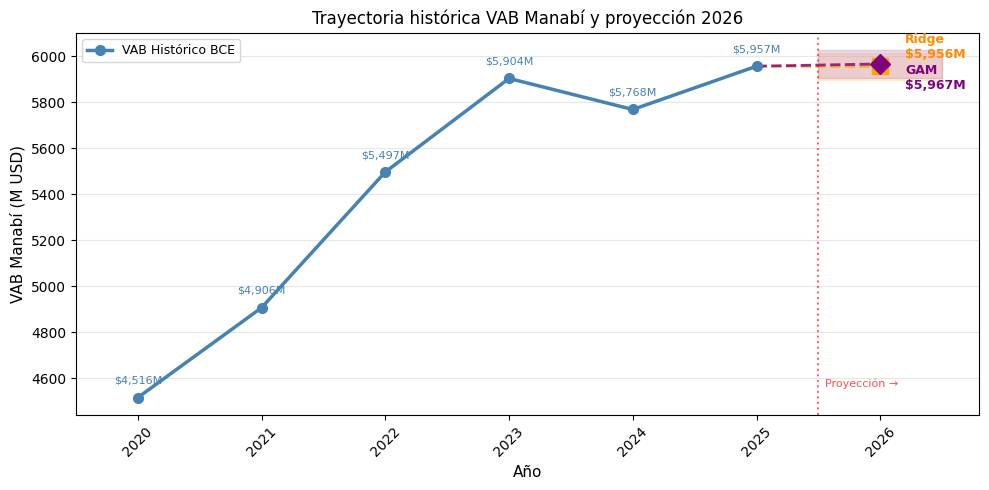

Guardada: figura_4a_trayectoria_2026.png


In [ ]:
# =================================================================
# FIGURA 4a — Trayectoria histórica + proyección anual 2026
# =================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Serie histórica
ax.plot(años_hist, vals_hist, 'o-', color='steelblue',
        linewidth=2.5, markersize=7, label='VAB Histórico BCE', zorder=3)

for yr, vl in vab_historico.items():
    ax.annotate(f'${vl:,.0f}M', (yr, vl),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=8, color='steelblue')

# Líneas hacia proyecciones
ax.plot([2025, 2026], [VAB_2025_REAL, vab_anual_ridge],
        '--', color='orange', linewidth=2, alpha=0.8)
ax.plot(2026, vab_anual_ridge, 's', color='orange', markersize=12, zorder=4)
ax.annotate(f'Ridge\n${vab_anual_ridge:,.0f}M',
            (2026, vab_anual_ridge),
            textcoords="offset points", xytext=(18, 6),
            ha='left', fontsize=9, color='darkorange', fontweight='bold')

ax.plot([2025, 2026], [VAB_2025_REAL, vab_anual_gam],
        '--', color='purple', linewidth=2, alpha=0.8)
ax.plot(2026, vab_anual_gam, 'D', color='purple', markersize=10, zorder=4)
ax.annotate(f'GAM\n${vab_anual_gam:,.0f}M',
            (2026, vab_anual_gam),
            textcoords="offset points", xytext=(18, -18),
            ha='left', fontsize=9, color='purple', fontweight='bold')

# Banda incertidumbre
ax.fill_between([2025.5, 2026.5], [ridge_lo]*2, [ridge_hi]*2,
                alpha=0.15, color='orange')
ax.fill_between([2025.5, 2026.5], [gam_lo]*2, [gam_hi]*2,
                alpha=0.15, color='purple')

ax.axvline(x=2025.5, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(2025.55, min(vals_hist)*1.01, 'Proyección →',
        fontsize=8, color='red', alpha=0.7)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('VAB Manabí (M USD)', fontsize=11)
ax.set_title('Trayectoria histórica VAB Manabí y proyección 2026', fontsize=12)
ax.set_xticks(años_hist + [2026])
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(2019.5, 2026.8)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('figura_4a_trayectoria_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada: figura_4a_trayectoria_2026.png")

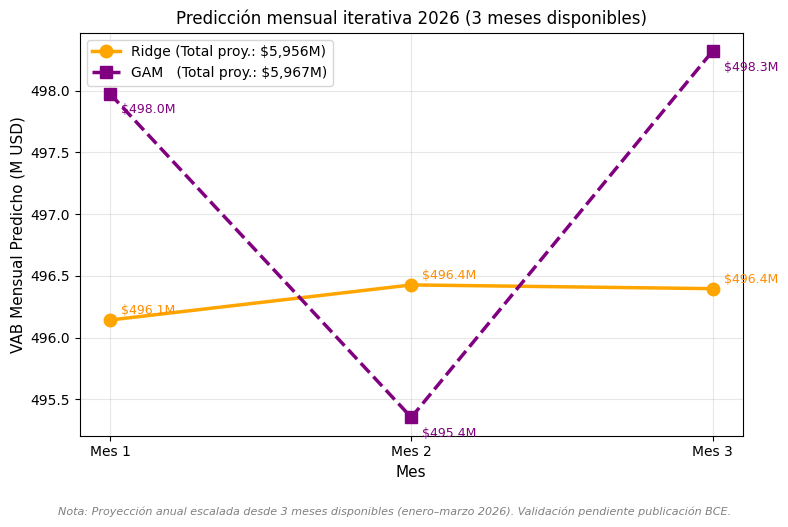

Guardada: figura_4b_mensual_2026.png


In [ ]:
# =================================================================
# FIGURA 4b — Predicción mensual enero-marzo 2026
# =================================================================

fig, ax = plt.subplots(figsize=(8, 5))

meses = df_pred_ridge['mes'].values

ax.plot(meses, df_pred_ridge['vab'], 'o-', color='orange',
        linewidth=2.5, markersize=9, label=f'Ridge (Total proy.: ${vab_anual_ridge:,.0f}M)')
ax.plot(meses, df_pred_gam['vab'], 's--', color='purple',
        linewidth=2.5, markersize=9, label=f'GAM   (Total proy.: ${vab_anual_gam:,.0f}M)')

for m, vr, vg in zip(meses, df_pred_ridge['vab'], df_pred_gam['vab']):
    ax.annotate(f'${vr:.1f}M', (m, vr),
                textcoords="offset points", xytext=(8, 4),
                fontsize=9, color='darkorange')
    ax.annotate(f'${vg:.1f}M', (m, vg),
                textcoords="offset points", xytext=(8, -14),
                fontsize=9, color='purple')

ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('VAB Mensual Predicho (M USD)', fontsize=11)
ax.set_title(f'Predicción mensual iterativa 2026 ({n} meses disponibles)', fontsize=12)
ax.set_xticks(meses)
ax.set_xticklabels([f'Mes {m}' for m in meses])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

fig.text(0.5, -0.04,
         f'Nota: Proyección anual escalada desde {n} meses disponibles (enero–marzo 2026). '
         f'Validación pendiente publicación BCE.',
         ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('figura_4b_mensual_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada: figura_4b_mensual_2026.png")